**Table of contents**

- [Data collection and preprocessing](#data-collection-and-preprocessing)
    - [Dataset selection](#dataset-selection)
    - [Data cleaning](#data-cleaning)
    - [More on Part of Speech](#more-on-part-of-speech)
- [Document representation](#document-representation)
    - [Continous bag of words (CBOW)](#continous-bag-of-words-cbow) 
    - [Document embeddings using `Doc2Vec`](#document-embeddings-using-doc2vec) 
    - [Document representation using TF-IDF](#document-representation-using-tf-idf)
- [Building search engine](#building-search-engine)
    - [Search engine: cosine similarity solution](#search-engine-cosine-similarity-solution)
    - [Search engine: K-means solution](#search-engine-k-means-solution)
        - [K-means: cluster visualization using t-SNE](#k-means-cluster-visualization-using-t-sne)
- [Evaluation](#evaluation)
    - [Metrics](#metrics)

- [Dependencies](#dependencies)
- [Author](#author)

# NLP: Middle-term project

This assignment aims to build a search engine that returns the most similar documents for a given query. This project uses embeddings to represent documents and similarity measures to retrieve the closest matches from a corpus. This can be applied to any domain with text data, such as news articles, scientific papers, or legal documents.

## Data collection and preprocessing

For this project I choose **Reuters corpus** available on **NLTK**, it's a collection of articles about news focused on financial topics. Below I've listed some details about Reuters:

- **Size** &rarr; Reuters is composed by $10.000$ articles, divide in $90$ different categories such as *market, science, sport, etc.*
- **Text type** &rarr; The articles are short and written in business english
- **Organization** &rarr; Each article is associated to its specific category, this stuff is usefull for classification problem or thematic search
- **Training and Test set** &rarr; Reuters corpus is alredy divided in labelled train and test set, this stuff helpful the evaluation phase

### Dataset selection

In [1]:
import numpy as np
import nltk                              
from nltk.corpus import reuters, wordnet, stopwords

"""# Useful packages
nltk.download('reuters')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
"""

# Load the documents of the training set
training_set = [
    {
        "text": reuters.raw(fileids=fileid),
        "categories": reuters.categories(fileid),
        "id": fileid,
        "tokens": reuters.words(fileid),
        "POS": []
    }
    for fileid in reuters.fileids() if fileid.startswith("training")
]

# Load the documents of the test set
test_set = [
    {
        "text": reuters.raw(fileids=fileid),
        "categories": reuters.categories(fileid),
        "id": fileid,
        "tokens": reuters.words(fileid),
        "POS": []
    }
    for fileid in reuters.fileids() if fileid.startswith("test")
]

# Load the reuteurs vocabulary [useful for the spell correction]
with open("./spell_checker/reuters_vocabulary.txt", "r") as file:
    vocabulary = [word.strip() for word in file]

### Data cleaning

The aim of our project is the *Document similarity search*, so I have applied theese clean on the data:

| **Cleaning operation** | **Justification** |
|:-:|:-:|
| To lowercase | To ensure uniformity in the word representation (avoid duplicate as *'house'* and *'House'*) |
| Punctuation removal | For text simplification |
| Tokenization | Split the text in single words in order to get an easy representation of the sentences, our corpus is already tokenized |
| Stop words removal | Remove the words that not influence the similarity |
| Part of Speech Calculation | The pos tags are useful for the lemmatization |
| Lemmatization | Reduce the words at their base form (lemma form), to avoid useless variants of the same word (ex. "runner"&rarr;"run") |

In [2]:
import re                                 # for regular expression
from nltk.stem import WordNetLemmatizer

# Penn Treebank Tagset -> Wordnet Tagset
def pennTrebankTS_to_wordnetTS(corpus):
    for document in corpus:
        document["POS"] = [
            (token, wordnet.ADJ if tag.startswith("J") else
                    wordnet.VERB if tag.startswith("V") else
                    wordnet.NOUN if tag.startswith("N") else
                    wordnet.ADV if tag.startswith("R") else tag)
            for token, tag in document["POS"]
        ]

# Preprocessing function
def clean_data(corpus):
    # Convert to lowercase all words in the whole corpus
    cleaned_corpus = [
    {
        "text": document["text"],
        "categories": document["categories"],
        "id": document["id"],
        "tokens": [token.lower() for token in document["tokens"]],
        "POS": []
    }
    for document in corpus
]
    # Puctuation removal
    for document in cleaned_corpus:
        document["tokens"] = [re.sub(r'[^\w\s]', '', token) for token in document["tokens"] if re.sub(r'[^\w\s]', '', token) != '']

    # Stop words removal
    stop_words = set(stopwords.words('english'))
    for document in cleaned_corpus:
        document["tokens"] = [token for token in document["tokens"] if token not in stop_words]

    # Part of speech calculation [the next markdown section contain insight about POS]
    for document in cleaned_corpus:
        document["POS"] = nltk.pos_tag(tokens=document["tokens"])

    # Convert all POS TAG in order to apply the lemmatization
    pennTrebankTS_to_wordnetTS(cleaned_corpus)
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    for document in cleaned_corpus:
        document["tokens"] = [
            lemmatizer.lemmatize(token[0], pos=token[1]) 
            if token[1] in [wordnet.NOUN, wordnet.VERB, wordnet.ADJ, wordnet.ADV] 
            else token[0]  # If POS is not recognized, keep original token
            for token in document["POS"]
        ]

    return cleaned_corpus

cleaned_training_set = clean_data(corpus=training_set)

### More on Part of Speech

The **Part of Speech (aka POS)** is an important procedure that is useful to tag each token (word) into a document in order to understand the role of words in the sentences, such as *names. verbs, adverbs, etc*. In this work I have used the function `nltk.pos_tag(tokens)`, given a tokens in input the function retrive a list whose each element is a couple of the token and its pos tag, in particular this function uses the **Penn treebank** as tagset. `pos_tag()` uses the **perceptron POS tagger** model to assign the tags to each token.

The Penn Treebank tagset is a widely used set of part-of-speech (POS) tags in natural language processing and computational linguistics, developed as part of the Penn Treebank Project at the University of Pennsylvania. This tagset consists of 36 POS tags, each representing a specific grammatical category such as noun, verb, adjective, adverb, etc., along with their variations. NLTK use this POS tags (with a little bit variations).

To apply the lemmatization I have used the lemmatizer `Wordnet Lemmatizer`, the inputs of this function are the **tokens** and their **pos tag**, actually, the Wordnet lemmatizer uses the **Wordnet POS tagset** instead of **Penn treebank POS tagset**, for this reason I have implemented a function to convert my "Penn treebank" tagset into "Wordnet" tagset.

## Document representation

The document representation is an important step for the NLP problems; the objective consist in the text transformation into a numerical representation, useful for the machines to understand the meaning of the words. Many algorithms exist to do this transformation.

### Continous bag of words (CBOW)

**Continous bag of words (CBOW)** is a model of **word embedding** and its aim consist to represent the words in a vector continous space, in this way two words that have the same semantics will be close.

As follow, the main aspects of the CBOW.

1. **Input** &rarr; The model receive in input the *context window* (of size $n$)
1. **Architecture** &rarr; CBOW is a simple model with one hidden layer with a **softmax** as activation function in order to get a probability distribution for all words in the document. The loss function used in this case is *Cross-entropy loss*.
1. **Output** &rarr; The model yield a vector that contain the means among the all context words

![CBOW architecture](images/CBOW_model.png)

I've used the model `Word2Vec` contained into the `Gensim` module that by default using the CBOW approach to do the word embedding. To reach the document representation (the our real objective in this section) is necessary to compute an averaging among the collected word embeddings.

In [3]:
from gensim.models import Word2Vec

# Tokenize the document and initialize the model with its hyperparameter
sentences = [document["tokens"] for document in cleaned_training_set]

model = Word2Vec(sentences=sentences, vector_size=300, window=5, min_count=1, workers=4)

# Document representation using the average of the CBOW word embeddings
def embedding_averaging(tokens, model):
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not word_vectors:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)

# Compute the embedding of each document using embedding average CBOW
documents_tokens = [document["tokens"] for document in cleaned_training_set]
document_representation_cbow = [embedding_averaging(document, model) for document in documents_tokens]

# First document embedding output
print(document_representation_cbow[0])

[-5.06365523e-02  3.26201499e-01 -4.71590549e-01 -4.49381694e-02
  2.36844912e-01 -5.69135025e-02  4.21355665e-01  6.42789066e-01
  5.87558895e-02 -1.75650075e-01  1.86812095e-02 -2.67600715e-01
 -1.56217292e-01 -2.38057226e-01 -4.13165718e-01 -1.34624794e-01
  2.99058825e-01  2.53109574e-01  1.94610596e-01  5.36550842e-02
  5.48045300e-02 -3.14816162e-02  9.68388394e-02 -1.15099795e-01
 -1.83177590e-02 -1.20790720e-01 -1.56064406e-01 -1.95318326e-01
 -3.16152066e-01 -4.59333807e-01  2.87547916e-01  9.40938219e-02
  1.17342696e-01 -1.32854804e-01 -3.63721885e-02  4.13879305e-01
  1.27424896e-01 -7.07677528e-02 -2.80184954e-01  6.74560964e-02
  4.77165543e-02  7.94517174e-02 -2.01208647e-02 -3.21681112e-01
  2.48260722e-01  4.31365222e-01 -1.03651285e-01 -2.57188305e-02
 -8.95590335e-02 -4.91461642e-02  1.59327611e-01 -2.77373591e-03
 -2.48555169e-01  1.97218090e-01  2.28338800e-02  3.11713368e-01
  9.56917554e-02  4.79551293e-02  1.62221700e-01 -1.97844490e-01
 -1.76233903e-01  2.44226

### Document embeddings using `Doc2Vec`

The document representation is even achived using the model `Doc2Vec` (a semi-supervised model), even this model is contained into the `Gensim` module. In this way we can avoid the averaging calculation and get directly the document representation. This one is a reliable and sofisticated way respect to the previous averaging approach. This model is more powerful on entire documents, meanwhile the CBOW approach is a good choose when the NLP task is simple or when we aren't interested about contextual correlations.

In [4]:
from gensim.models.doc2vec import Doc2Vec,TaggedDocument

# Tag each document with an unique ID (index), TaggedDocument yield couples ["tokens", "doc_tag"]
tagged_data = [TaggedDocument(words=document["tokens"], tags=[str(i)]) for i, document in enumerate(cleaned_training_set)]
print(tagged_data[1][1]) # <- print the index of the document [1]

# doc2vec hyperparameter settings
model_doc2vec = Doc2Vec(vector_size=300, window=5, min_count=1, workers=4, epochs=10, dm=1)

# make vocaboulary of all words
model_doc2vec.build_vocab(tagged_data)

# Train the model
model_doc2vec.train(tagged_data, total_examples=model_doc2vec.corpus_count, epochs=model_doc2vec.epochs)

# compute the document embedding for each document (document representation)
document_representation_doc2vec = [model_doc2vec.infer_vector(document["tokens"]) for document in cleaned_training_set]

['1']


### Document representation using TF-IDF

Another alternative to the averaging approach is the **Term frequency-Inverse document frequency (TF-IDF)**, this tool allow us to assign a weight (the importance of a word) to the words contained into the documents.

$$
\text{TF-IDF}_{t,d} = TF_{t,d} \times IDF_t
$$

#### Term frequency (TF)

This formula indicate the frequency of a term $t$ in a single document $d$.

$$
TF_{t,d} = \frac{\text{\#occurs of t in d}}{\text{\#words in d}}
$$

#### Document frequency (DF)

The notation $DF_{t}$ indicate the **document frequency**, this denote the number of documents that include the term $t$.

$$
DF_t = |{d\in D:t \in d}| 
$$
$$
D \text{ is the corpus }
$$

#### Inverse document frequency (IDF)

This formula compute the weight of a word using its rarity into the corpus, common words (such as *"the", "and", "is", ecc*) will have a low IDF value, while, rare words will have a higher IDF value.

$$
IDF_t = \log_{10}\left(\frac{N}{DF_t}\right)
$$
$$
N \text{ is the total number of document in the corpus}
$$

#### TF-IDF: implementation

For the TF-IDF calculation I've used the `TfidfVectorizer` tool included into the `scikit-learn` module, by default this tool apply an $\text{L2}$ normalization and a smoothed IDF. This function work on document passed as string, so I have to convert each tokenized document into a single string, this conversion lead to loose the metadata about document, such as *id* and *categories*.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Tokenized documents -> String
tokens_as_string = [' '.join(document["tokens"]) for document in cleaned_training_set]

# Store the metadatas, to kept the main information about document
document_ids = [document["id"] for document in cleaned_training_set]
document_categories = [document["categories"] for document in cleaned_training_set]

# TF-IDF matrix calculation
vectorizer = TfidfVectorizer(min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(tokens_as_string)  # Each row is a document, each column is a term

# Get the vocaboulary used during the vectorization (useful for inspection) 
tfidf_feature_names = vectorizer.get_feature_names_out()

I check if the scores retrived by the vectorization are reasonable, for the check I have used the document with ID `training/10`.

In [6]:
# Raw text of the document [test/14828]
print(f"Raw text [{cleaned_training_set[1]['id']}]\n\n {cleaned_training_set[1]['text']}")

# Display the TF-IDF scores for the first document
print("TF-IDF scores for the document [1]:")
doc_tfidf_scores = zip(tfidf_feature_names, tfidf_matrix[1].toarray()[0])
for term, score in sorted(doc_tfidf_scores, key=lambda x: -x[1])[:10]:
    print(f"{term}: {score:.4f}")

Raw text [training/10]

 COMPUTER TERMINAL SYSTEMS &lt;CPML> COMPLETES SALE
  Computer Terminal Systems Inc said
  it has completed the sale of 200,000 shares of its common
  stock, and warrants to acquire an additional one mln shares, to
  &lt;Sedio N.V.> of Lugano, Switzerland for 50,000 dlrs.
      The company said the warrants are exercisable for five
  years at a purchase price of .125 dlrs per share.
      Computer Terminal said Sedio also has the right to buy
  additional shares and increase its total holdings up to 40 pct
  of the Computer Terminal's outstanding common stock under
  certain circumstances involving change of control at the
  company.
      The company said if the conditions occur the warrants would
  be exercisable at a price equal to 75 pct of its common stock's
  market price at the time, not to exceed 1.50 dlrs per share.
      Computer Terminal also said it sold the technolgy rights to
  its Dot Matrix impact technology, including any future
  improvements, 

## Building search engine

"Search engine" is a definition that has a different interpretation depending from the task, in our scenario a **search engine** is a software that find the documents (in a collection of documents) that have the maximum similarity respect to a given query passed as input. We could build this engine in different ways, and in this project we will implement the following solutions:

* Search engine based on the **cosine similarity**
* Search engine using a clustering machine learning model, in particular, the **K-means** alghoritm

### Search engine: cosine similarity solution

The **cosine similarity** is a tool useful to compute the similarity among two vectors in term of space orientation, its formulation is very simple:

$$
\text{cosine\_similarity} = \cos(\beta) = \frac{\hat{v} \cdot \hat{w}}{||\hat{v}|| \cdot ||\hat{w}||}
$$

The cosine similarity yield a float value in the interval $[-1,1]$, where $1$ indicates are identical, $0$ indicates that the vectors are completely different (the vectors are orthogonal), while $-1$ indicates that the vectors are opposite.

In this section I will use this tool to build a search engine that retrive the first $k$ document that have the maximum cosine similarity respect to the query; I have used the **TF-IDF** as document representation.

I have used the `cosine_similarity(X,Y)` function contained into the `sklearn.metrics.pairwise` module, that yield a matrix where each element $(i,j)$ contain the similarity score among the the vector $i$ of $X$ and the vector $j$ of $Y$.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import word_tokenize

"""
    Cosine Similarity Search Engine

    Uses cosine similarity to retrieve the top-k most similar documents 
    from a corpus with respect to the provided query.

    Parameters:
    --------------------
    query : str
        The query string to compare against the corpus.
    k : int, optional
        The number of top similar documents to retrieve (default is 5).

    Returns:
    --------------------
    list[int]
        A sorted list containing the indices of the top-k most similar documents 
        in the corpus, ordered by descending similarity.
""" 

def cosine_similarity_search_engine(query, k=5, embedding_method="tfidf"):
    # Compute the query embeddings
    tokenized_query = word_tokenize(query, language="english")
    if embedding_method == "TF-IDF":
        query_tfidf = vectorizer.transform([query])
        cosine_similarities = cosine_similarity(query_tfidf, tfidf_matrix)
    elif embedding_method == "CBOW":
        query_average = embedding_averaging(tokens=tokenized_query, model=model)
        cosine_similarities = cosine_similarity([query_average], document_representation_cbow)
    elif embedding_method == "DOC2VEC":
        query_doc2vec = model_doc2vec.infer_vector(tokenized_query)
        cosine_similarities = cosine_similarity(query_doc2vec.reshape(1,-1),document_representation_doc2vec)

    #Take the first K document that have greater similarity
    top_k_by_index = cosine_similarities.argsort()[0][-k:][::-1]

    return top_k_by_index, cosine_similarities[0][top_k_by_index]

# Print the document insights given a list of document indices
def print_document_by_index(document_index, corpus, similarity_scores):
    for id, score in zip(document_index, similarity_scores):
        print(f"Document ID: [{corpus[id]['id']}]")
        print(f"Document Index: [{id}]")
        print(f"Cosine similarity score: [{score:.4f}]\n")
        print(corpus[id]["text"])

Now I try the engine with submitting different query to the engine.

ℹ️: The query and k-value can be passed using the widgets implemented using the `IPythonWidgets` module.

In [17]:
import ipywidgets as widgets
from IPython.display import display
from spell_checker import SpellingCorrector

# Text field for query input
query_input = widgets.Text(
    value = '',
    placeholder = "Type a query here...",
    description = "Query:",
    disabled = False
)

spell_corrector_checkbox = widgets.Checkbox(
    value = False,
    description = "Spell correction on query"
)

# Integer input for K value input
k_input = widgets.IntText(
    value=5,
    placeholder="Enter a K value...",
    description="Top-k:",
    disabled=False
)

embedding_mode = widgets.RadioButtons(
    options = ["CBOW", "DOC2VEC", "TF-IDF"],
    description = "Choose embeddings modality"
)

# Output widget
output_result = widgets.Output()

# Event handler
def cosine_engine_handler(change):
    output_result.clear_output()
    
    # For spell correction
    if spell_corrector_checkbox.value:
        query = SpellingCorrector.SpellCorrector(query_input.value, vocabulary).retrive_corrected()
    else:
        query = query_input.value.lower()
    
    k = k_input.value
    top_k, similarity_scores = cosine_similarity_search_engine(query, k, embedding_method=embedding_mode.value)
    
    with output_result: 
        print(f"Query: {query}\n")
        print_document_by_index(document_index=top_k, corpus=cleaned_training_set, similarity_scores=similarity_scores)

query_input.observe(cosine_engine_handler)
k_input.observe(cosine_engine_handler)
embedding_mode.observe(cosine_engine_handler)
display(query_input, spell_corrector_checkbox, k_input, embedding_mode, output_result)

Text(value='', description='Query:', placeholder='Type a query here...')

Checkbox(value=False, description='Spell correction on query')

IntText(value=5, description='Top-k:')

RadioButtons(description='Choose embeddings modality', options=('CBOW', 'DOC2VEC', 'TF-IDF'), value='CBOW')

Output()

### Search engine: K-means solution

The **K-means** is an unsupervised clustering algorithm widely used to divide the data into a $k$ distinct groups (called cluster). As follow the main steps to apply this algorithm.

1. **Initialization**: $k$ initial points, called centroids, are chosen to represent the center of the clusters. They can be selected randomly
1. **Assigning points to cluster**: Each point in the dataset is assigned to the cluster whose centroid is closest, using a distance metric (typically the Euclidean distance)
1. **Updating centroids**: For each cluster, the centroid is recalculated as the mean of the points assigned to that cluster
1. **Iteration**: The assignment and update steps are repeated until the centroids no longer change significantly, or a maximum number of iterations is reached

In this section I have implemented a search engine based on K-means, using the model contained into the module `sklearn.cluster`.

In [9]:
from sklearn.cluster import KMeans

# Model init and train
K = 15
kmeans_model = KMeans(n_clusters=K, random_state=42)
kmeans_model.fit(tfidf_matrix)

"""
    K-Means Search Engine

    Uses K-means clustering algorithm to find the document with 
    maximum similarity against the query

    Parameters:
    --------------------
    query : str
        The query string to compare against the corpus.
    model : KMeans
        Trained K-means model using sklearn
    n : int, default=5
        The number of top similar documents to retrieve
    
    Returns:
    --------------------
    list[int]
        A sorted list containing the indices of the top-n most similar documents 
        in the corpus and their index, ordered by descending similarity.
""" 
def k_means_search_engine(query, n=5):
    # Query embedding
    embedding_query = vectorizer.transform([query.lower()])

    # Take the cluster to which our query belongs
    query_cluster_label = kmeans_model.predict(embedding_query)[0]

    # Get the indices of all document that belong to the same cluster of the query input
    cluster_indices = np.where(kmeans_model.labels_ == query_cluster_label)[0]

    # Pick the tfidf matrix that contains only the document of our domain
    cluster_documents = tfidf_matrix[cluster_indices]

    # compute the cosine similarity among the query and the document of the same cluster
    cosine_similarities = cosine_similarity(embedding_query, cluster_documents)[0]

    # Get the first n documents with maximum similarity against the query
    top_n = np.argsort(cosine_similarities)[::-1][:n]

    # Get ID and Similarity score for each n document retrived
    similar_corpora = [(cluster_indices[i], cosine_similarities[i]) for i in top_n]

    return similar_corpora

Now we can try our K-means model. Even in this case I have used user interface provided by `IPyWidgets`.

In [18]:
# Text field for query input
query_input = widgets.Text(
    value = '',
    placeholder = "Type a query here...",
    description = "Query:",
    disabled = False
)

# Integer input for K value input
n_input = widgets.IntText(
    value=5,
    placeholder="Enter the depth search value...",
    description="N:",
    disabled=False
)

# Output widget
output_result = widgets.Output()

# Event handler
def kmeans_engine_handler(change):
    output_result.clear_output()
    query = query_input.value.lower()
    n = n_input.value
    results = k_means_search_engine(query, n)
    
    with output_result:
        for doc_idx, sim in results:
            print(f"Document ID: {cleaned_training_set[doc_idx]['id']}")
            print(f"Document index: {doc_idx}")
            print(f"Cosine similarity: {sim:.4f}\n")
            print(f"{cleaned_training_set[doc_idx]['text']}\n")
        
query_input.observe(kmeans_engine_handler)
n_input.observe(kmeans_engine_handler)
display(query_input, n_input, output_result)

Text(value='', description='Query:', placeholder='Type a query here...')

IntText(value=5, description='N:')

Output()

#### K-means: cluster visualization using t-SNE

<p style="color:red; font-weight: bold;">THEORETICAL CONCEPTS TODO</p>

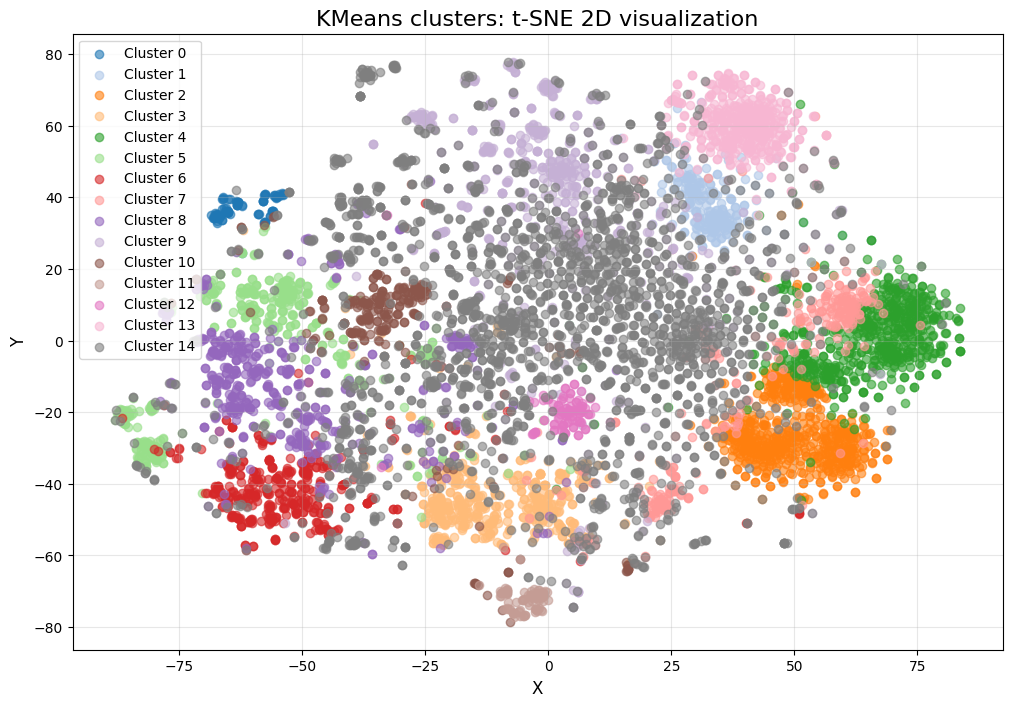

In [19]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Dimensionality reduction to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
reduced_data_tsne = tsne.fit_transform(tfidf_matrix.toarray())

# Achive the k-means cluster labels
cluster_labels = kmeans_model.labels_

# Initialize the plot
plt.figure(figsize=(12,8))

# Use 20 different colors from the color map "tab20"
colors = plt.colormaps["tab20"]

# Plot the cluster points on the 2D plane
for cluster in range(K):
    cluster_points = reduced_data_tsne[cluster_labels == cluster]
    plt.scatter(
        # [:, 0] -> All x coordinates for cluster points
        # [:, 1] -> All y coordinates for cluster points
        cluster_points[:, 0], cluster_points[:, 1],
        color=colors(cluster),
        label=f"Cluster {cluster}",
        alpha=0.6
    )

# Draw plot
plt.title("KMeans clusters: t-SNE 2D visualization", fontsize=16)
plt.xlabel("X", fontsize=12)
plt.ylabel("Y", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

## Evaluation

<p style="color:red; font-weight: bold;">TODO</p>



### Metrics

In [12]:
from sklearn.metrics import confusion_matrix

cleaned_test = clean_data(corpus=test_set)

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import numpy as np

# Funzione per ottenere le etichette predette per il test set
def get_cluster_labels_for_test_set(test_set, kmeans_model, vectorizer):
    # Preprocessa i documenti di test
    test_documents = [doc['text'] for doc in test_set]
    tfidf_test_matrix = vectorizer.transform(test_documents)
    
    # Ottieni le etichette dei cluster per ogni documento del test_set
    cluster_labels = kmeans_model.predict(tfidf_test_matrix)
    
    return cluster_labels

# Mappa dei cluster alle categorie reali
def map_clusters_to_categories(test_set, kmeans_model, vectorizer):
    cluster_labels = get_cluster_labels_for_test_set(test_set, kmeans_model, vectorizer)
    
    # Crea una lista di etichette reali per i documenti di test
    true_labels = [doc['categories'] for doc in test_set]  # Potrebbero esserci più categorie per documento
    
    # Mappa ogni cluster alla categoria più frequente nei suoi documenti
    cluster_to_category = {}
    for cluster in range(kmeans_model.n_clusters):
        # Trova i documenti appartenenti a questo cluster
        cluster_indices = np.where(cluster_labels == cluster)[0]
        category_counts = {}
        
        for idx in cluster_indices:
            for category in true_labels[idx]:
                if category not in category_counts:
                    category_counts[category] = 0
                category_counts[category] += 1
        
        # Mappa il cluster alla categoria più frequente
        most_common_category = max(category_counts, key=category_counts.get)
        cluster_to_category[cluster] = most_common_category
    
    # Crea le etichette previste per il test set in base ai cluster
    predicted_labels = [cluster_to_category[cluster] for cluster in cluster_labels]
    
    return predicted_labels, true_labels

def calculate_metrics(test_set, kmeans_model, vectorizer):
    # Ottieni le etichette previste e reali
    predicted_labels, true_labels = map_clusters_to_categories(test_set, kmeans_model, vectorizer)
    
    # Creare una lista di etichette reali e previste per ogni categoria
    flattened_true_labels = []
    flattened_predicted_labels = []
    
    # Per ogni documento nel test set
    for true, predicted in zip(true_labels, predicted_labels):
        for category in true:
            flattened_true_labels.append(category)  # Aggiungi ogni categoria vera
            flattened_predicted_labels.append(predicted)  # Aggiungi la categoria prevista
    
    # Verifica che il numero di etichette corrisponda
    if len(flattened_true_labels) != len(flattened_predicted_labels):
        print(f"Inconsistency found: {len(flattened_true_labels)} != {len(flattened_predicted_labels)}")
        return None, None, None, None
    
    # Calcolare Precision, Recall e F1
    precision = precision_score(flattened_true_labels, flattened_predicted_labels, average='weighted')
    recall = recall_score(flattened_true_labels, flattened_predicted_labels, average='weighted')
    f1 = f1_score(flattened_true_labels, flattened_predicted_labels, average='weighted')
    
    # Report di classificazione
    class_report = classification_report(flattened_true_labels, flattened_predicted_labels)
    
    return precision, recall, f1, class_report

# Esegui la funzione con il tuo test set e modello
precision, recall, f1, class_report = calculate_metrics(cleaned_test, kmeans_model, vectorizer)

if precision is not None:
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", class_report)

Precision: 0.4257
Recall: 0.5168
F1 Score: 0.4361

Classification Report:
                  precision    recall  f1-score   support

            acq       0.38      0.99      0.55       719
           alum       0.00      0.00      0.00        23
         barley       0.00      0.00      0.00        14
            bop       0.00      0.00      0.00        30
        carcass       0.00      0.00      0.00        18
     castor-oil       0.00      0.00      0.00         1
          cocoa       0.00      0.00      0.00        18
        coconut       0.00      0.00      0.00         2
    coconut-oil       0.00      0.00      0.00         3
         coffee       0.00      0.00      0.00        28
         copper       0.00      0.00      0.00        18
     copra-cake       0.00      0.00      0.00         1
           corn       0.00      0.00      0.00        56
         cotton       0.00      0.00      0.00        20
     cotton-oil       0.00      0.00      0.00         2
            

c:\Users\garem\miniconda3\envs\nltk\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\garem\miniconda3\envs\nltk\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\garem\miniconda3\envs\nltk\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\User



## Dependencies

- [`re`](https://docs.python.org/3/library/re.html)
- [`numpy`](https://numpy.org/)
- [`matplotlib`](https://matplotlib.org/)
- [`sklearn`](https://scikit-learn.org/stable/)
- [`nltk`](https://www.nltk.org/)
- [`gensim`](https://radimrehurek.com/gensim/)
- [`IPyWidgets`](https://ipywidgets.readthedocs.io/en/stable/)

## Author

*Emilio Garzia* (mat. 0124/314)